![](COMCHA_Banner.png)

<font size="30">Machine Learning for global fits</font>

Tutorial by Jorge Alda (U. Padova & INFN Padova & CAPA Zaragoza).

Tutorials for the session "ML for global fits" of [4th COMCHA school](https://indico.capa.unizar.es/event/42), celebrated in Zaragoza (Spain), 8-15 April 2026.

# 0: Data preparation

In [2]:
from urllib.request import urlretrieve
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import HTML
HTML('''<script>
    Reveal.initialize({
        background: '#cccccc'
    });
</script>''')



import alpaca
from alpaca_chi2 import run_coeffs

alpaca.info()

# ALP-aca

[![Version](https://img.shields.io/badge/version-1.2.0-teal?logo=GitHub)](https://github.com/alp-aca/alp-aca/tree/v1.2.0-alpha.1)
[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.16447036.svg)](https://doi.org/10.5281/zenodo.16447036) [![arxiv](https://img.shields.io/badge/arXiv-2508.08354_[hep--ph]-B31B1B.svg?style=flat&logo=arxiv&logoColor=B31B1B)](https://arxiv.org/abs/2508.08354)

Welcome to the ALP Automated Computed Algorithm (ALP-aca)!

![ALPaca logo](https://raw.githubusercontent.com/alp-aca/alp-aca/main/docs/_static/logo.png)

ALP-aca is an open-source Python library for the phenomenology of Axion-Like Particles (ALPs) with masses in the ranges of $m_a \sim 0.01 - 10\,\mathrm{GeV}$, mainly in processes involving mesons.

ALP-aca integrates the full analysis with an easy-to-use syntax:

* Matching of selected UV-complete models (DFSZ-like, KSVZ-like, flaxions, etc.) to the ALP-EFT.
* Numerical running and matching of the ALP-EFT coefficients down to the physical relevant scales, including ALP-$\chi\!$ PT.
* Calulation of decay rates for processes involving ALPs:
  * ALP production in rare meson decays $M_1\to M_2 a$, quarkonia decays $V\to \gamma a$ and non-resonant production $e^+e^- \to \gamma a$,
  * ALP decays into photons, leptons and mesons,
  * Processes mediated by on-shell ALPs in the Narrow Width Approximation,
  * Leptonic and radiative meson decays, and meson mixing, with off-shell ALPs.
* Calculation of ALP decay lengths and probability of decaying outside the detector, with a displaced vertex or in the prompt region.
* $\chi^2$ statistical analysis, with fine-grained control of the observables and experimental measurements included.
* Generation of publication-grade exclusion plots.
* Automatic management of the bibliographical references used in the analysis.

## The ALP-aca team

* **Jorge Alda**: Università degli Studi di Padova & INFN Sezione di Padova & CAPA Zaragoza.
* **Marta Fuentes Zamoro**: Universidad Autónoma de Madrid & IFT Madrid.
* **Luca Merlo**: Universidad Autónoma de Madrid & IFT Madrid.
* **Xavier Ponce Díaz**: University of Basel.
* **Stefano Rigolin**: Università degli Studi di Padova & INFN Sezione di Padova.

## ALP-aca in action

In [this repositoy](https://github.com/alp-aca/examples) you can find examples, tutorials and applications of ALP-aca.

ALP-aca has been used in the following publications:

* J. Alda, M. Fuentes Zamoro, L. Merlo, X. Ponce Díaz, S. Rigolin: *Comprehensive ALP searches in Meson Decays*. [arXiv:2507.19578](https://arxiv.org/abs/2507.19578)

If you have used ALP-aca in your publication and want to be featured in this list, please [contact us](https://github.com/alp-aca/alp-aca/issues/new?template=publication-using-alpaca.md).

## Installation

ALP-aca can be installed with `pip`:

```bash
pip3 install alpaca-ALPs
```

The plotting backends, `matplotlib` and `plotly`, are not included as depencencies of ALP-aca, but they can be installed as optional dependencies. To install with `matplotlib`

```bash
pip3 install alpaca-ALPs[matplotlib]
```

with `plotly`

```bash
pip3 install alpaca-ALPs[plotly]
```

and with both

```bash
pip3 install alpaca-ALPs[matplotlib,plotly]
```

It is *strongly recommended* to install ALP-aca inside a virtual environment (venv), in order to avoid clashes with conflicting versions of the dependencies. In order to create a venv, execute the following command

```bash
python3 -m venv pathToVenv
```

where `pathToVenv` is the location where the files of the venv will be stored. In order to activate the venv, for Linux or MacOS using `bash` or `zsh`

```bash
source pathToVenv/bin/activate
```

For Windows using ```cmd.exe```

```bat
C:\> pathToVenv\Scripts\Activate.bat
```

And for Windows using ```PowerShell```

```powershell
PS C:\> path_to_venv\Scripts\Activate.ps1
```

Once the venv is activated, ALPaca can be normally installed and used.

## Citing ALP-aca

If you use ALP-aca, please cite

```bibtex
@article{Alda:2025nsz,
    author = "Alda, Jorge and Fuentes Zamoro, Marta and Merlo, Luca and Ponce D{\'\i}az, Xavier and Rigolin, Stefano",
    title = "{ALPaca: The ALP Automatic Computing Algorithm}",
    eprint = "2508.08354",
    archivePrefix = "arXiv",
    primaryClass = "hep-ph",
    reportNumber = "IFT-UAM/CSIC-25-82",
    month = "8",
    year = "2025"
}

@software{alda_2025_16447036,
  author       = {Alda, Jorge and
                  Fuentes Zamoro, Marta and
                  Merlo, Luca and
                  Rigolin, Stefano and
                  Ponce Díaz, Xavier},
  title        = {ALPaca v1.0},
  month        = jul,
  year         = 2025,
  publisher    = {Zenodo},
  version      = {v1.0.0},
  doi          = {10.5281/zenodo.16447036},
  url          = {https://doi.org/10.5281/zenodo.16447036},
}
```

## Documentation

The ALPaca manual for v1.0.0 is available on [arXiv](https://arxiv.org/abs/2508.08354). For newer versions, check the changelogs:

* [v1.1.0 (31 October 2025)](https://github.com/alp-aca/alp-aca/blob/main/changelogs/v1-1.md)
* [v1.2.0-alpha.1 (28 March 2026)](https://github.com/alp-aca/alp-aca/blob/main/changelogs/v1-2.md)

You can also check the [automatically-generated documentation](https://alpaca-alps.readthedocs.io/latest/).

Try also the AI-powered wiki and assistant: [![Ask DeepWiki](https://deepwiki.com/badge.svg)](https://deepwiki.com/alp-aca/alp-aca)

## Feedback

If you encounter bugs or want to propose a new feature, you can contact us using [Gihub issues](https://github.com/alp-aca/alp-aca/issues/new/choose).



First we download the training data from [DOI 10.5281/zenodo.19235291](https://zenodo.org/records/19235291)

In [2]:
url = "https://zenodo.org/records/19235291/files/comcha_alp_bknunu_training.csv?download=1"
urlretrieve(url, 'dataset.csv')

with open('dataset.csv', "rb") as f:
    digest = hashlib.file_digest(f, "md5")
if digest.hexdigest() == 'b45e606923b223db32201ac0706afa8e':
    print('Dataset has been downloaded correctly!')
else:
    print('There is an issue with the integrity of the dataset. Please try downloading again')

Dataset has been downloaded correctly!


Let's examine a bit the dataset

In [3]:
df = pd.read_csv('dataset.csv')

In [4]:
df.describe()

,fa,cqL33,cuR,cdR,clL33,ceR,chi2
count,4.163800e+04,41638.000000,41638.000000,41638.000000,41638.000000,41638.000000,41638.000000
mean,6.652833e+06,0.050626,0.048345,0.314527,-0.209264,-0.005942,38.311924
std,4.284938e+06,0.986689,1.692169,1.737798,1.689726,0.482145,29.898190
min,9.890659e+05,-3.004338,-3.493465,-3.268823,-3.262673,-3.056907,12.764648
25%,3.128176e+06,-0.558564,-1.382927,-1.179884,-1.626480,-0.261317,15.528566
50%,6.335120e+06,0.000087,0.040222,0.575058,-0.378622,0.014125,17.654180
75%,9.116607e+06,0.720883,1.509588,1.834466,1.169829,0.275564,80.000000
max,3.297181e+07,3.118538,3.220710,3.230848,3.245655,3.076858,80.000000


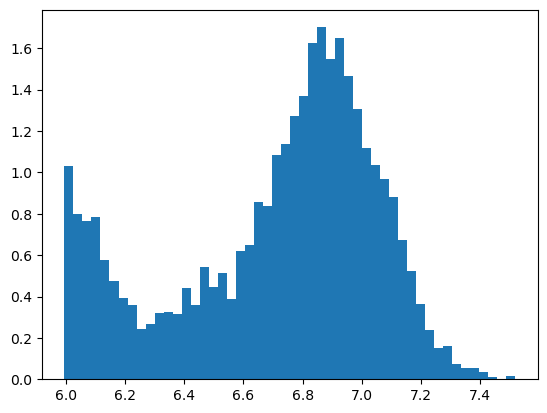

In [5]:
_ = plt.hist(np.log10(df['fa']), bins=50, density = True)

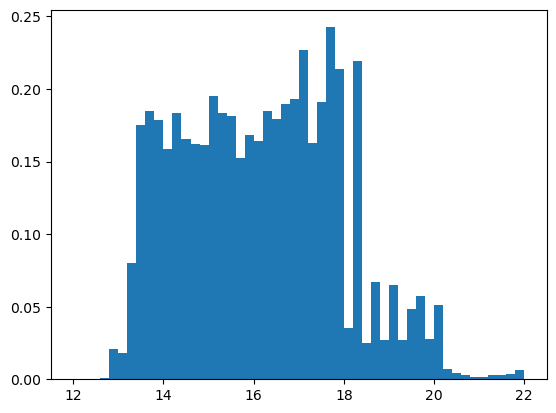

In [6]:
_ = plt.hist(df['chi2'], bins=50, density=True, range=(12, 22))

And prepare the features for the model:

In [7]:
df['cqL33/fa'] = df['cqL33'] / df['fa']
df['cuR/fa'] = df['cuR'] / df['fa']
df['cdR/fa'] = df['cdR'] / df['fa']
df['clL33/fa'] = df['clL33'] / df['fa']
df['ceR/fa'] = df['ceR'] / df['fa']
df['log_fa'] = np.log10(df['fa'])
X = df[['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa', 'chi2']]

In [8]:
X.to_csv('sample_tutorial.csv', index=False)

In [9]:
bf = df[['fa', 'cqL33', 'cuR', 'cdR', 'clL33', 'ceR']].iloc[np.argmin(df['chi2'])]

In [10]:
bf_couplings = run_coeffs(*bf)

bf_couplings

### ALP couplings
- Scale: $2.00$ GeV
- Basis: ```VA_below```
- EW scale: $10^{2}$ GeV
<details><summary>Couplings:</summary>

- $c_u^V = \begin{pmatrix}1.99 - 2.00\times10^{-22}\,i & 2.99\times10^{-9} - 3.44\times10^{-9}\,i \\2.99\times10^{-9} + 3.44\times10^{-9}\,i & 1.99 - 5.55\times10^{-17}\,i \end{pmatrix}$
- $c_u^A = \begin{pmatrix}1.95 - 1.12\times10^{-20}\,i & -2.99\times10^{-9} + 3.44\times10^{-9}\,i \\-2.99\times10^{-9} - 3.44\times10^{-9}\,i & 1.95 - 5.55\times10^{-17}\,i \end{pmatrix}$
- $c_d^V = \begin{pmatrix}1.74 + 3.69\times10^{-22}\,i & -7.04\times10^{-4} - 2.97\times10^{-4}\,i & 1.71\times10^{-2} + 6.84\times10^{-3}\,i \\-7.04\times10^{-4} + 2.97\times10^{-4}\,i & 1.74 + 2.22\times10^{-16}\,i & -8.40\times10^{-2} + 1.57\times10^{-3}\,i \\1.71\times10^{-2} - 6.84\times10^{-3}\,i & -8.40\times10^{-2} - 1.57\times10^{-3}\,i & 3.77 - 2.68\times10^{-20}\,i \end{pmatrix}$
- $c_d^A = \begin{pmatrix}1.70 - 1.22\times10^{-20}\,i & 7.04\times10^{-4} + 2.97\times10^{-4}\,i & -1.71\times10^{-2} - 6.84\times10^{-3}\,i \\7.04\times10^{-4} - 2.97\times10^{-4}\,i & 1.70 + 2.22\times10^{-16}\,i & 8.40\times10^{-2} - 1.57\times10^{-3}\,i \\-1.71\times10^{-2} + 6.84\times10^{-3}\,i & 8.40\times10^{-2} + 1.57\times10^{-3}\,i & -3.30\times10^{-1} + 1.50\times10^{-20}\,i \end{pmatrix}$
- $c_e^V = \begin{pmatrix}-1.53\times10^{-1} + 3.77\times10^{-23}\,i & 0.00 & 0.00 \\0.00 & -1.53\times10^{-1} + 3.77\times10^{-23}\,i & 0.00 \\0.00 & 0.00 & 5.57\times10^{-1} + 3.77\times10^{-23}\,i \end{pmatrix}$
- $c_e^A = \begin{pmatrix}-1.47\times10^{-1} - 5.24\times10^{-22}\,i & 0.00 & 0.00 \\0.00 & -1.47\times10^{-1} - 5.24\times10^{-22}\,i & 0.00 \\0.00 & 0.00 & -8.56\times10^{-1} - 5.24\times10^{-22}\,i \end{pmatrix}$
- $c_\nu = \begin{pmatrix}-7.77\times10^{-4} - 5.24\times10^{-22}\,i & 0.00 & 0.00 \\0.00 & -7.77\times10^{-4} - 5.24\times10^{-22}\,i & 0.00 \\0.00 & 0.00 & 7.08\times10^{-1} - 5.24\times10^{-22}\,i \end{pmatrix}$
- $c_G = 0.00$
- $c_\gamma = 0.00$
</details>


In [11]:
chi2_bf = alpaca.statistics.get_chi2(alpaca.sectors.default_sectors['all'], 2.0, bf_couplings, bf['fa'], integrator='no_rge').split_observables()

In [12]:
sigmas = [(c, s) for (c, s) in [(c, c.significance()) for c in chi2_bf] if s>0]

sigmas

[(ChiSquared(sector="delta_mBs"), array([0.52620153])),
 (ChiSquared(sector="B+ -> K+ alp"), array([0.76858297])),
 (ChiSquared(sector="KL -> electron electron"), array([0.04860914])),
 (ChiSquared(sector="delta_mK0"), array([0.49937258])),
 (ChiSquared(sector="delta_mB0"), array([0.27126216])),
 (ChiSquared(sector="ASL_Bs"), array([0.22218561])),
 (ChiSquared(sector="Bs -> muon muon"), array([0.72058999])),
 (ChiSquared(sector="KS -> photon photon"), array([1.17028326])),
 (ChiSquared(sector="KL -> muon muon"), array([1.48420722])),
 (ChiSquared(sector="epsK"), array([1.93034407])),
 (ChiSquared(sector="B+ -> K*+ alp"), array([0.1261265])),
 (ChiSquared(sector="ASL_B0"), array([0.95139533]))]